In [10]:
#source activate newEnv
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
library(tibble)
library(broom)
library("parallel")
library(tidyr)
library(stringr)
#library(pheatmap)
library(qvalue)

ERROR: Error in library(pheatmap): there is no package called ‘pheatmap’


In [2]:
cells <- scan('/nfs/lab/tscc/rlmelton/liver_HOMER/liver_data/listofcells.txt', what="", sep="\n")
cells

[1] "B"             "Cholangiocyte" "Endothelial"   "Hepatocytes"  
 [5] "HSC"           "Mast"          "Myeloid"       "NK"           
 [9] "Schwann"       "T"             "Bulk"

In [3]:
diseases= c('Fibrosis.stage', 'MASH_ALL_vs_Control', 'MASH_vs_Control', 'MASL_vs_Control', 'MetALD_vs_Control','fibrosis')
modalities <- c('H3K27ac','H3K27me3','ATAC',
                'H3K27ac_ATAC_Peaks','H3K27ac_TSS','H3K27me3_ATAC_Peaks','H3K27me3_TSS')
sig_level <- c('nominal','padj')
direction <- c('up','down')
trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
background_beds <- list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/', full.names = TRUE)


In [4]:
celltypes <- c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')
subtypes <- c('Activated.HSC','B','Central.Vein.Endothelial','Cholangiocyte',
              'Hepatocytes.Senescent','Hepatocytes.Stress','Hepatocytes.Zone1',
              'Hepatocytes.Zone2','Hepatocytes.Zone3','Kupffer','Lipid.Associated.Macrophage',
             'Lymphatic.Endothelial','Macrophage','Mast','Mesenchymal','NK','Plasma',
             'Quescent.HSC','Schwann','Sinusoidal.Endothelial','T','Vascular.Endothelial')
Hepato_subtypes <- c('Hepatocytes.Senescent','Hepatocytes.Stress','Hepatocytes.Zone1',
              'Hepatocytes.Zone2','Hepatocytes.Zone3')
Endo_subtypes <- c('Central.Vein.Endothelial','Sinusoidal.Endothelial','Vascular.Endothelial','Lymphatic.Endothelial')
HSC_subtypes <- c('Activated.HSC','Quescent.HSC','Mesenchymal')
Myeloid_subtypes <- c('Kupffer','Lipid.Associated.Macrophage','Macrophage')

In [5]:
#dir.create('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [6]:
trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
#background_beds <- list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/', full.names = TRUE)
bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/'

In [7]:
setwd('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [13]:
out.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/'

In [14]:
Sys.time()
commands <- character()

for(MOD in modalities){
    message(MOD)

    for(DIRECT in direction){
        message(DIRECT)
        for(SIG in sig_level){
            message(SIG)
            for (CELL in cells){
                #message(CELL)
                for (disease_num in 1:length(diseases)){
                    input_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/%s.%s_%s.dds.res.%s.%s.bed', MOD, CELL,diseases[disease_num],SIG, DIRECT))
                    if (file.exists(str_replace(input_name, '/tscc/projects/ps-gaultonlab','/nfs/lab/tscc'))) {
                        
                        if(MOD %in% c('H3K27ac','H3K27me3','H3K27ac_ATAC_Peaks','H3K27me3_ATAC_Peaks','H3K27ac_TSS','H3K27me3_TSS')){
                            background_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/%s.%s_background.bed', MOD, CELL))

                        }else if (MOD %in% c('ATAC')) {
                           background_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/%s_union.peaks', CELL))

                        }
                        
                        commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'_',MOD,'_',DIRECT,'_',SIG,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
                    }
                }
            }
        }
    }
}

bed.dir.tscc <- str_replace(bed.dir, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')
#Cell type specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed'
for (CELL in celltypes){
    input_name <- paste0(bed.dir.tscc, CELL, "_specific_5k.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#Sub type specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/subtype_union_peaks.bed'
for (CELL in subtypes){
    input_name <- paste0(bed.dir.tscc, CELL, "_subtype_specific_5k.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#Hepatocytes subtypes specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Hepatocyte_only_union_peaks.bed'
for (CELL in Hepato_subtypes){
    input_name <- paste0(bed.dir.tscc, CELL, "_Hepatocytes_specific_5k.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#Endothelial subtypes specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Endothelial_only_union_peaks.bed'
for (CELL in Endo_subtypes){
    input_name <- paste0(bed.dir.tscc, CELL, "_Endothelial_specific_5k.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#HSC subtypes specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/HSC_only_union_peaks.bed'
for (CELL in HSC_subtypes){
    input_name <- paste0(bed.dir.tscc, CELL, "_HSC_specific_5k.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#Myeloid subtypes specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Myeloid_only_union_peaks.bed'
for (CELL in Myeloid_subtypes){
    input_name <- paste0(bed.dir.tscc, CELL, "_Myeloid_specific_5k.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

for (CELL in c('Hepatocytes','Myeloid','HSC','Endothelial')) {
    background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241217_WE_',CELL,'_disease_differential_background_clusters.bed')
    clusters <- c('_disease_differential_MASH_clusters.bed', '_disease_differential_MASH_on_clusters.bed', 
                  '_disease_differential_MASH_specific_cluste', '_disease_differential_MASL_clusters.bed', 
                  '_disease_differential_MASL_on_clusters.bed', '_disease_differential_MASL_specific_cluste', 
                  '_disease_differential_MetALD_clusters.bed')
    input_name <- paste0(bed.dir.tscc,'241217_WE_', CELL, clusters)
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
    
    background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241217_WE_',CELL,'_disease_background_clusters.bed')
    clusters <- c('_disease_MASH_clusters.bed', '_disease_MASH_on_clusters.bed', 
                  '_disease_MASH_specific_cluste', '_disease_MASL_clusters.bed', 
                  '_disease_MASL_on_clusters.bed', '_disease_MASL_specific_cluste', 
                  '_disease_MetALD_clusters.bed')
    input_name <- paste0(bed.dir.tscc,'241217_WE_', CELL, clusters)
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

Sys.time()

length(commands)
head(commands)

commands[str_detect(commands, 'nfs')]

[1] "2024-12-17 15:34:51 PST"

H3K27ac

up

nominal

padj

down

nominal

padj

H3K27me3

up

nominal

padj

down

nominal

padj

ATAC

up

nominal

padj

down

nominal

padj

H3K27ac_ATAC_Peaks

up

nominal

padj

down

nominal

padj

H3K27ac_TSS

up

nominal

padj

down

nominal

padj

H3K27me3_ATAC_Peaks

up

nominal

padj

down

nominal

padj

H3K27me3_TSS

up

nominal

padj

down

nominal

padj



[1] "2024-12-17 15:35:23 PST"

[1] 856

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_Fibrosis.stage.dds.res.nominal.up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/B_H3K27ac_up_nominal__H3K27ac.B_Fibrosis.stage.dds.res.nominal.up.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                                
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/B_H3K27ac_up_nominal__H3K27ac.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                      
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MASH_vs_Control.dds.res.nominal.up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/B_H3K27ac_up_nominal__H3K27ac.B_MASH_vs_Control.dds.res.nominal.up.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                              
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MASL_vs_Control.dds.res.nominal.up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/B_H3K27ac_up_nominal__H3K27ac.B_MASL_vs_Control.dds.res.nominal.up.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                              
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.B_MetALD_vs_Control.dds.res.nominal.up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/B_H3K27ac_up_nominal__H3K27ac.B_MetALD_vs_Control.dds.res.nominal.up.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.B_background.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                          
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27ac.Cholangiocyte_Fibrosis.stage.dds.res.nominal.up.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/Cholangiocyte_H3K27ac_up_nominal__H3K27ac.Cholangiocyte_Fibrosis.stage.dds.res.nominal.up.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27ac.Cholangiocyte_background.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

character(0)

In [12]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241217_commands_HOMER.txt',col.names=F, row.names=F, quote=F, sep='\t')

In [15]:
Sys.time()
commands <- character()

background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed'
for (CELL in celltypes){
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
    
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#Sub type specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/subtype_union_peaks.bed'
for (CELL in subtypes){
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks_subtypes.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
    
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks_subtypes.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#Hepatocytes subtypes specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/Hepatocyte_only_union_peaks.bed'
for (CELL in Hepato_subtypes){
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks_Hepatocytes.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
    
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks_Hepatocytes.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

#HSC subtypes specific peaks
background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/HSC_only_union_peaks.bed'
for (CELL in HSC_subtypes){
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_marker_peaks_HSC.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
    
    input_name <- paste0(bed.dir.tscc, '241216_WE_',CELL, "_Yang_specific_peaks_HSC.bed")
    
    commands <- c(commands, paste0('findMotifsGenome.pl ',input_name, ' hg38 ', 
                                                       out.dir,CELL,'__',
                                                       str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),
                                                       '/ -size 200 -bg ',background_name,' -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
}

Sys.time()

length(commands)
head(commands)

commands[str_detect(commands, 'nfs')]

[1] "2024-12-18 12:43:12 PST"

[1] "2024-12-18 12:43:12 PST"

[1] 80

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_B_Yang_marker_peaks.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/B__241216_WE_B_Yang_marker_peaks.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                        
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_B_Yang_specific_peaks.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/B__241216_WE_B_Yang_specific_peaks.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"                                    
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Cholangiocyte_Yang_marker_peaks.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/Cholangiocyte__241216_WE_Cholangiocyte_Yang_marker_peaks.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"    
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Cholangiocyte_Yang_specific_peaks.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/Cholangiocyte__241216_WE_Cholangiocyte_Yang_specific_peaks.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Endothelial_Yang_marker_peaks.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/Endothelial__241216_WE_Endothelial_Yang_marker_peaks.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"          
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241216_WE_Endothelial_Yang_specific_peaks.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/Endothelial__241216_WE_Endothelial_Yang_specific_peaks.bed/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/celltype_union_peaks.bed -mknown 240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

character(0)

In [17]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241218_commands_HOMER.txt',col.names=F, row.names=F, quote=F, sep='\t')

# Celltype Markers

In [3]:
results.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/outs/'

In [114]:
results.dfs <- list()
cells <- scan('/nfs/lab/tscc/rlmelton/liver_HOMER/liver_data/listofcells.txt', what="", sep="\n")
cells <- cells[cells !='Bulk']

for (cell in cells) {
    df2 <- vroom::vroom(paste0(results.dir, cell, '__241216_WE_',cell,'_Yang_marker_peaks.bed/knownResults.txt'))
    df2$comparison <- paste0(cell,'.markers')
    df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
    df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
    #Fold change and Log2 Fold change calculation
    FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
    df2$FC<-FC
    L2FC<-log2(abs(FC))
    df2$L2FC<-L2FC
    #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
    # do Log2FC)
    df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
    df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
    df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
    #df3<-df2[df2$padj < .1, ]
    #renaming and rearranging columns because i can't stand the way it looks
    df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
               Perc_Background_Motif=`% of Background Sequences with Motif`, comparison, FC, L2FC, `-Log10p`, padj)
    results.dfs[[cell]] <- df3
}


Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

In [115]:
results.df <- bind_rows(results.dfs, .id = "cell.type")

dim(results.df)
head(results.df)

[1] 6920   10

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B,MA0076.2_ELK4,1e-280,23.23,11.68,B.markers,1.988870,0.9919489,280,6.920000e-278
B,MA0098.3_ETS1,1e-257,15.23,6.41,B.markers,2.375975,1.2485197,257,3.460000e-255
B,MA0645.1_ETV6,1e-239,19.19,9.40,B.markers,2.041489,1.0296220,239,2.306667e-237
B,MA0764.3_ETV4,1e-234,14.58,6.29,B.markers,2.317965,1.2128588,234,1.730000e-232
B,MA1708.1_ETV7,1e-232,22.92,12.30,B.markers,1.863415,0.8979487,232,1.384000e-230
B,MA0746.2_SP3,1e-230,40.14,26.63,B.markers,1.507323,0.5919882,230,1.153333e-228


In [116]:
write.table(results.df, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Celltype_Marker_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

In [117]:
results.df %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df)

Joining with `by = join_by(Motif.Name)`


Motif.Name,sig.motif,cell.type,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MA0003.4_TFAP2A,FALSE,B,1e+00,18.42,18.97,B.markers,0.9710069,-0.042446617,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,Cholangiocyte,1e+00,17.91,19.57,Cholangiocyte.markers,0.9151763,-0.127878419,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,Endothelial,1e+00,18.48,18.96,Endothelial.markers,0.9746835,-0.036994207,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,Hepatocytes,1e+00,17.02,18.85,Hepatocytes.markers,0.9029178,-0.147333486,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,HSC,1e+00,18.34,20.07,HSC.markers,0.9138017,-0.130046978,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,Mast,1e+00,21.01,20.84,Mast.markers,1.0081574,0.011720884,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,Myeloid,1e+00,15.29,15.37,Myeloid.markers,0.9947951,-0.007528758,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,NK,1e+00,17.97,19.52,NK.markers,0.9205943,-0.119362644,0,1.000000e+00
MA0003.4_TFAP2A,FALSE,Schwann,1e+00,19.09,21.18,Schwann.markers,0.9013220,-0.149885487,0,1.000000e+00


Joining with `by = join_by(Motif.Name)`


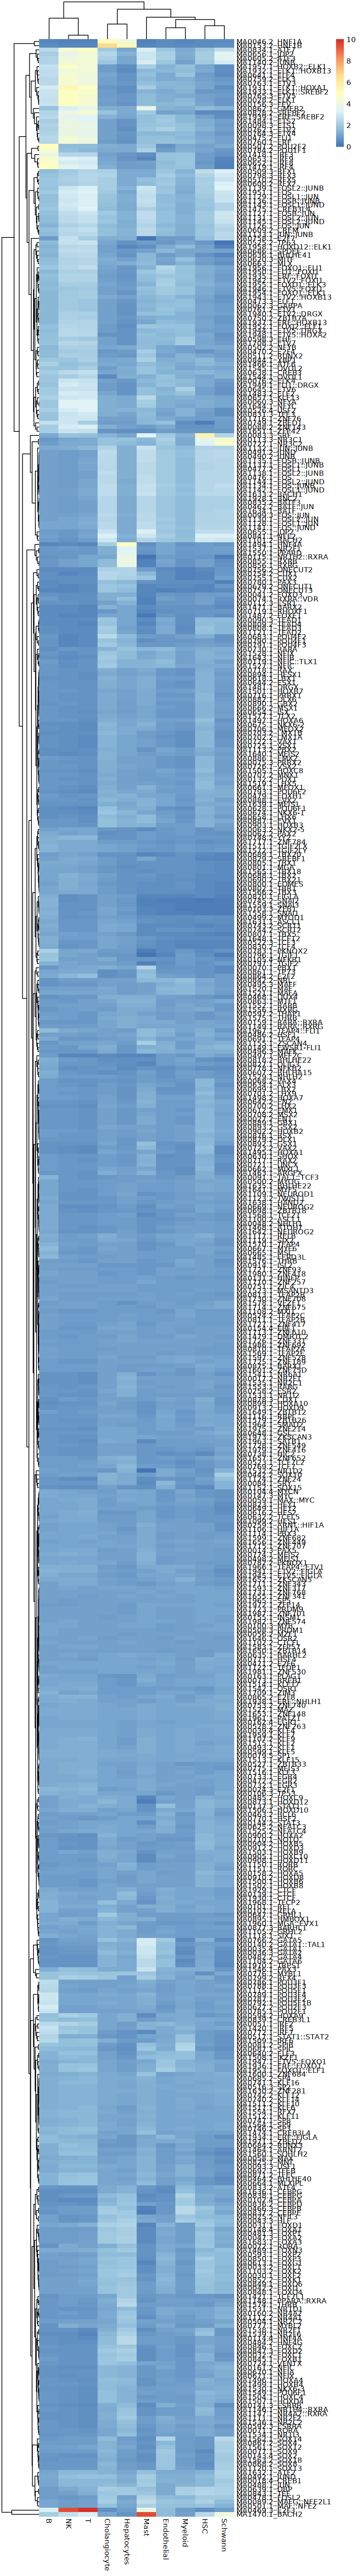

In [120]:
options(repr.plot.height=50)

results.df %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap()

In [156]:
results.df %>%
  group_by(cell.type) %>%                # Group by cell type
  slice_max(FC, n = 5, with_ties = FALSE) %>% # Select top 5 rows based on FC
  ungroup()

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B,MA1419.1_IRF4,1e-53,1.16,0.23,B.markers,5.043478,2.334419,53,9.105263e-53
B,MA0507.2_POU2F2,1e-119,2.72,0.55,B.markers,4.945455,2.306103,119,1.821053e-118
B,MA0784.2_POU1F1,1e-73,1.78,0.38,B.markers,4.684211,2.227806,73,1.098413e-72
B,MA0652.1_IRF8,1e-61,1.52,0.33,B.markers,4.606061,2.203533,61,9.479452e-61
B,MA0653.1_IRF9,1e-45,1.14,0.25,B.markers,4.560000,2.189034,45,8.238095e-45
Cholangiocyte,MA0153.2_HNF1B,1e-307,7.48,1.11,Cholangiocyte.markers,6.738739,2.752479,307,3.460000e-305
Cholangiocyte,MA0046.2_HNF1A,1e-307,8.27,1.60,Cholangiocyte.markers,5.168750,2.369815,307,3.460000e-305
Cholangiocyte,MA0841.1_NFE2,1e-90,3.49,1.08,Cholangiocyte.markers,3.231481,1.692196,90,1.870270e-89
Cholangiocyte,MA1101.2_BACH2,1e-81,3.62,1.23,Cholangiocyte.markers,2.943089,1.557331,81,1.730000e-80


Joining with `by = join_by(Motif.Name)`


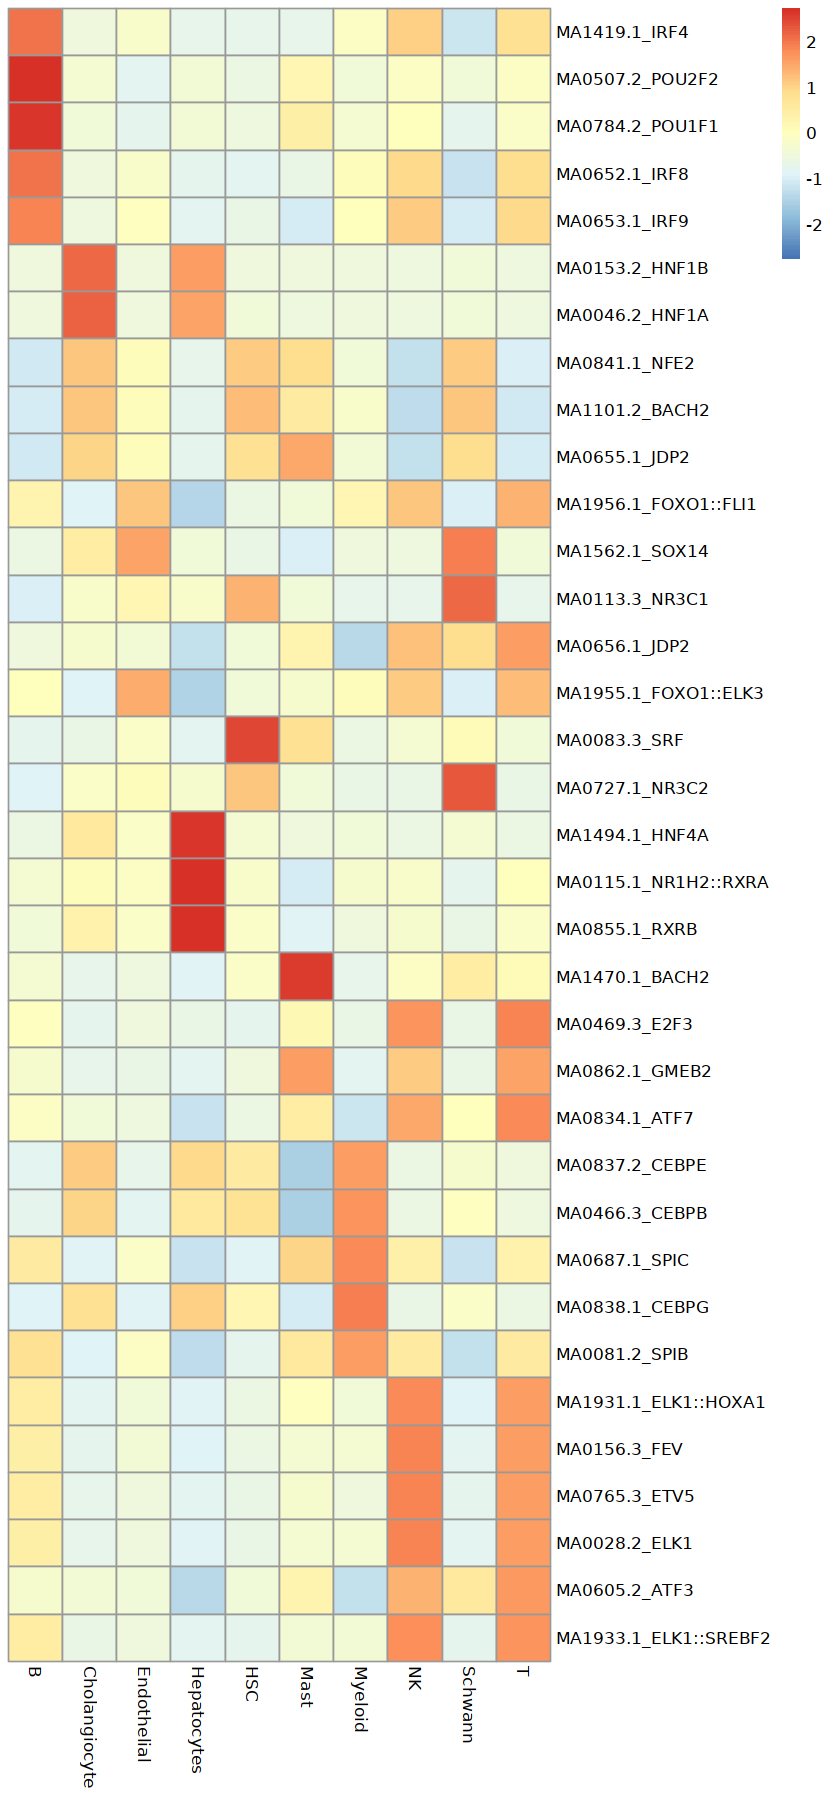

In [163]:
options(repr.plot.height=15)

results.df %>%
  group_by(cell.type) %>%                # Group by cell type
  slice_max(FC, n = 5, with_ties = FALSE) %>% # Select top 5 rows based on FC
  ungroup() %>%
    mutate(Motif.Name=factor(Motif.Name, levels=unique(Motif.Name))) %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap(scale='row', cluster_cols = F, cluster_rows = F)

Joining with `by = join_by(Motif.Name)`


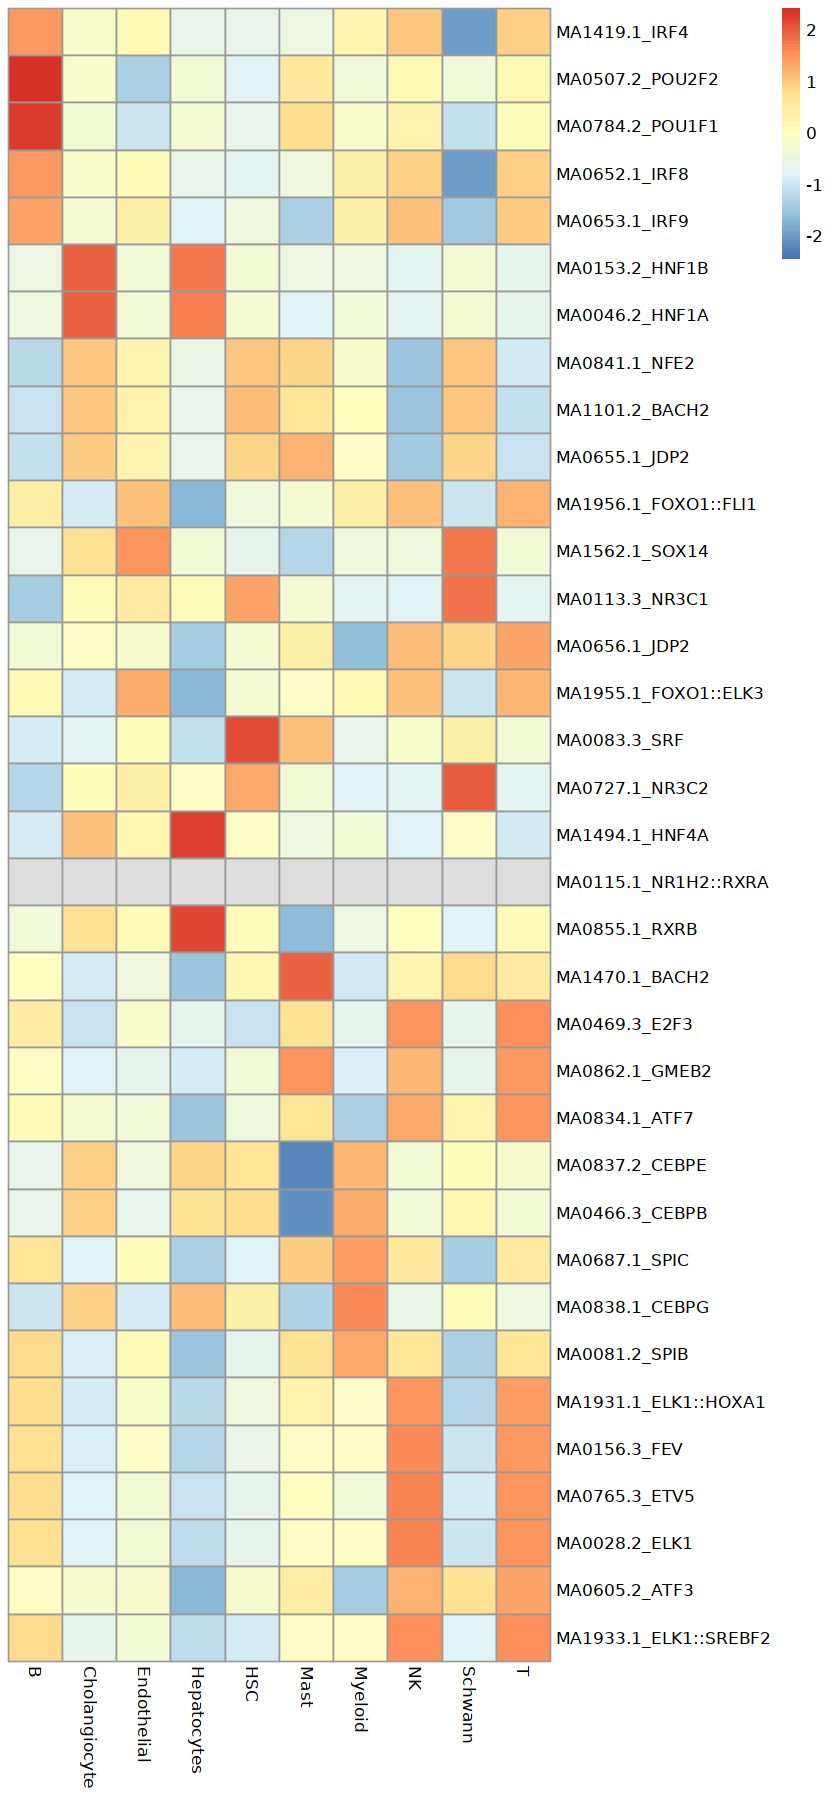

In [166]:
options(repr.plot.height=15)

results.df %>%
  group_by(cell.type) %>%                # Group by cell type
  slice_max(L2FC, n = 5, with_ties = FALSE) %>% # Select top 5 rows based on L2FC
  ungroup() %>%
    mutate(Motif.Name=factor(Motif.Name, levels=unique(Motif.Name))) %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, L2FC) %>%
    pivot_wider(values_from = L2FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap(scale='row', cluster_cols = F, cluster_rows = F)

# Celltype Specific

In [168]:
results.df.specific <- list()
cells <- scan('/nfs/lab/tscc/rlmelton/liver_HOMER/liver_data/listofcells.txt', what="", sep="\n")
cells <- cells[cells !='Bulk']

for (cell in cells) {
    df2 <- vroom::vroom(paste0(results.dir, cell, '__241216_WE_',cell,'_Yang_specific_peaks.bed/knownResults.txt'))
    df2$comparison <- paste0(cell,'.markers')
    df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
    df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
    #Fold change and Log2 Fold change calculation
    FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
    df2$FC<-FC
    L2FC<-log2(abs(FC))
    df2$L2FC<-L2FC
    #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
    # do Log2FC)
    df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
    df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
    df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
    #df3<-df2[df2$padj < .1, ]
    #renaming and rearranging columns because i can't stand the way it looks
    df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
               Perc_Background_Motif=`% of Background Sequences with Motif`, comparison, FC, L2FC, `-Log10p`, padj)
    results.df.specific[[cell]] <- df3
}


Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

In [169]:
results.df.specific <- bind_rows(results.df.specific, .id = "cell.type")

dim(results.df.specific)
head(results.df.specific)

[1] 6920   10

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B,MA0627.2_POU2F3,1e-190,15.17,3.33,B.markers,4.555556,2.1876270,190,6.920000e-188
B,MA0792.1_POU5F1B,1e-160,14.21,3.43,B.markers,4.142857,2.0506261,160,3.460000e-158
B,MA1115.1_POU5F1,1e-155,16.36,4.60,B.markers,3.556522,1.8304670,155,2.306667e-153
B,MA0785.1_POU2F1,1e-146,12.89,3.08,B.markers,4.185065,2.0652500,146,1.730000e-144
B,MA0789.1_POU3F4,1e-128,11.08,2.57,B.markers,4.311284,2.1081176,128,1.384000e-126
B,MA0103.3_ZEB1,1e-125,37.16,20.03,B.markers,1.855217,0.8915881,125,1.153333e-123


In [123]:
write.table(results.df.specific, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Celltype_Specific_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

Joining with `by = join_by(Motif.Name)`


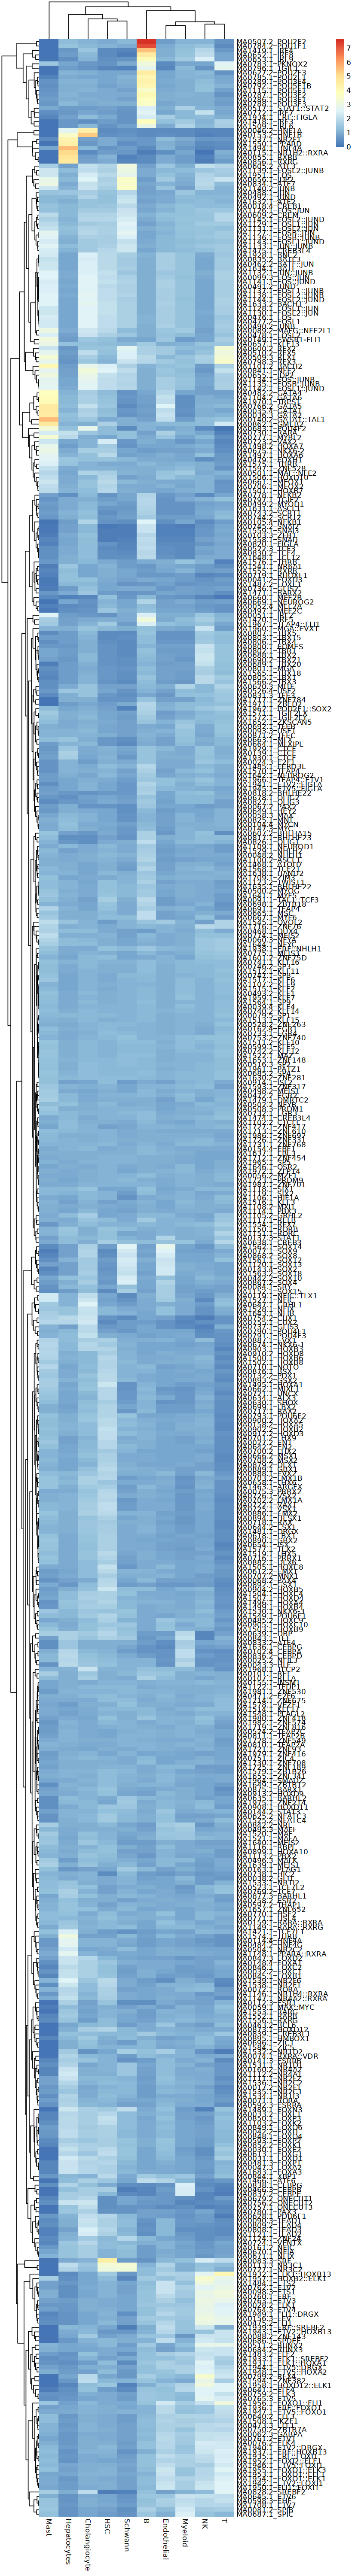

In [124]:
options(repr.plot.height=50)

results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap()

In [ ]:
results.df.specific

In [171]:
results.df.specific %>%
  group_by(cell.type) %>%                # Group by cell type
  slice_max(FC, n = 5, with_ties = FALSE) %>% # Select top 5 rows based on FC
  ungroup() 

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
B,MA0507.2_POU2F2,1e-117,6.24,0.82,B.markers,7.609756,2.927850,117,8.650000e-116
B,MA0784.2_POU1F1,1e-75,4.18,0.58,B.markers,7.206897,2.849378,75,3.844444e-74
B,MA1419.1_IRF4,1e-30,2.03,0.37,B.markers,5.486486,2.455883,30,2.162500e-29
B,MA0652.1_IRF8,1e-30,2.45,0.53,B.markers,4.622642,2.208717,30,2.162500e-29
B,MA0627.2_POU2F3,1e-190,15.17,3.33,B.markers,4.555556,2.187627,190,6.920000e-188
Cholangiocyte,MA0153.2_HNF1B,1e-148,9.17,1.71,Cholangiocyte.markers,5.362573,2.422925,148,6.920000e-146
Cholangiocyte,MA0046.2_HNF1A,1e-136,10.29,2.35,Cholangiocyte.markers,4.378723,2.130510,136,3.460000e-134
Cholangiocyte,MA0841.1_NFE2,1e-42,4.58,1.40,Cholangiocyte.markers,3.271429,1.709921,42,2.232258e-41
Cholangiocyte,MA0655.1_JDP2,1e-61,7.90,2.72,Cholangiocyte.markers,2.904412,1.538246,61,2.471429e-60


Joining with `by = join_by(Motif.Name)`


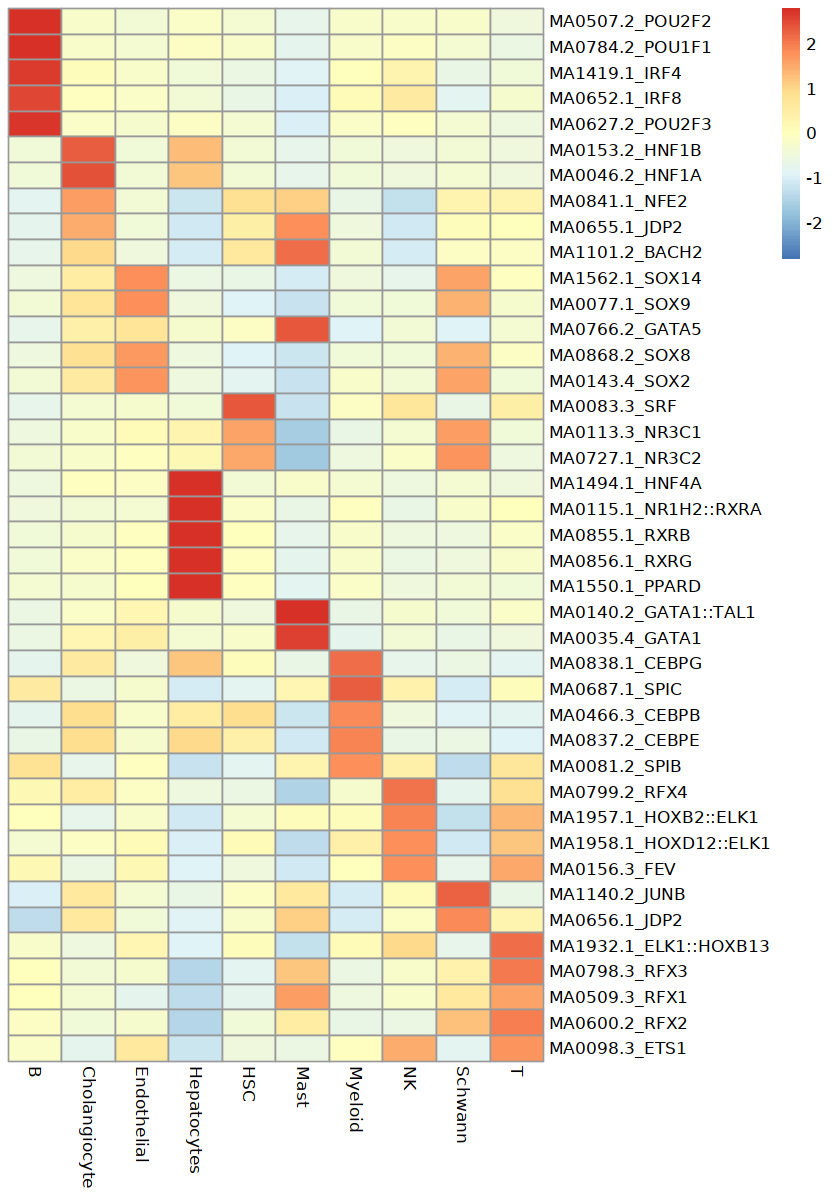

In [176]:
options(repr.plot.height=10)

results.df.specific %>%
  group_by(cell.type) %>%                # Group by cell type
  slice_max(FC, n = 5, with_ties = FALSE) %>% # Select top 5 rows based on FC
  ungroup() %>%
    mutate(Motif.Name=factor(Motif.Name, levels=unique(Motif.Name))) %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>% 
    pheatmap(scale='row', cluster_cols = F, cluster_rows = F)

# Hepatocyte Markers

In [4]:
results.df.specific <- list()
cells <- c('Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3','Hepatocytes.Senescent','Hepatocytes.Stress')

for (cell in cells) {
    df2 <- vroom::vroom(paste0(results.dir, cell, '__241216_WE_',cell,'_Yang_marker_peaks_Hepatocytes.bed/knownResults.txt'))
    df2$comparison <- paste0(cell,'.markers')
    df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
    df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
    #Fold change and Log2 Fold change calculation
    FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
    df2$FC<-FC
    L2FC<-log2(abs(FC))
    df2$L2FC<-L2FC
    #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
    # do Log2FC)
    df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
    df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
    df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
    #df3<-df2[df2$padj < .1, ]
    #renaming and rearranging columns because i can't stand the way it looks
    df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
               Perc_Background_Motif=`% of Background Sequences with Motif`, comparison, FC, L2FC, `-Log10p`, padj)
    results.df.specific[[cell]] <- df3
}


Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types

In [7]:
write.table(results.df.specific, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Hepatocyte_Marker_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

In [127]:
results.df.specific <- bind_rows(results.df.specific, .id = "cell.type")

dim(results.df.specific)
head(results.df.specific)

[1] 3460   10

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Hepatocytes.Zone1,MA1117.1_RELB,0.01,16.13,3.74,Hepatocytes.Zone1.markers,4.312834,2.1086363,2,1
Hepatocytes.Zone1,MA0079.5_SP1,0.10,38.71,21.43,Hepatocytes.Zone1.markers,1.806346,0.8530745,1,1
Hepatocytes.Zone1,MA0738.1_HIC2,0.10,29.03,14.01,Hepatocytes.Zone1.markers,2.072091,1.0510876,1,1
Hepatocytes.Zone1,MA0630.1_SHOX,0.10,6.45,0.76,Hepatocytes.Zone1.markers,8.486842,3.0852278,1,1
Hepatocytes.Zone1,MA1532.2_NR1D2,0.10,6.45,0.85,Hepatocytes.Zone1.markers,7.588235,2.9237644,1,1
Hepatocytes.Zone1,MA0442.2_SOX10,0.10,19.35,7.82,Hepatocytes.Zone1.markers,2.474425,1.3070931,1,1


In [8]:
results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif)

Joining with `by = join_by(Motif.Name)`


Motif.Name,sig.motif,cell.type,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MA0018.4_CREB1,TRUE,Hepatocytes.Zone1,1e+00,3.23,5.21,Hepatocytes.Zone1.markers,0.6199616,-0.6897492,0,1.000000e+00
MA0018.4_CREB1,TRUE,Hepatocytes.Zone2,1e+00,0.00,8.64,Hepatocytes.Zone2.markers,0.0000000,-Inf,0,1.000000e+00
MA0018.4_CREB1,TRUE,Hepatocytes.Zone3,1e+00,5.08,4.14,Hepatocytes.Zone3.markers,1.2270531,0.2951977,0,1.000000e+00
MA0018.4_CREB1,TRUE,Hepatocytes.Senescent,1e-13,15.40,7.19,Hepatocytes.Senescent.markers,2.1418637,1.0988667,13,2.386207e-12
MA0018.4_CREB1,TRUE,Hepatocytes.Stress,1e+00,4.65,6.28,Hepatocytes.Stress.markers,0.7404459,-0.4335338,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Zone1,1e+00,0.00,1.95,Hepatocytes.Zone1.markers,0.0000000,-Inf,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Zone2,1e+00,0.00,9.04,Hepatocytes.Zone2.markers,0.0000000,-Inf,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Zone3,1e+00,1.69,1.89,Hepatocytes.Zone3.markers,0.8941799,-0.1613630,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Senescent,1e-02,4.52,2.63,Hepatocytes.Senescent.markers,1.7186312,0.7812600,2,4.094675e-02


In [9]:
#options(repr.plot.height=50)
#
#results.df.specific %>%
#    group_by(Motif.Name) %>%
#    summarise(sig.motif=any(padj < 0.05)) %>%
#    full_join(results.df.specific) %>%
#    filter(sig.motif) %>%
#    select(cell.type, Motif.Name, FC) %>%
#    pivot_wider(values_from = FC, names_from = cell.type) %>%
#    tibble::column_to_rownames(var='Motif.Name') %>%
#    pheatmap()

ERROR: Error in pheatmap(.): could not find function "pheatmap"


# Hepatocytes Specific

In [11]:
results.df.specific <- list()
cells <- c('Hepatocytes.Zone1','Hepatocytes.Zone2','Hepatocytes.Zone3','Hepatocytes.Senescent','Hepatocytes.Stress')

for (cell in cells) {
    df2 <- vroom::vroom(paste0(results.dir, cell, '__241216_WE_',cell,'_Yang_specific_peaks_Hepatocytes.bed/knownResults.txt'))
    df2$comparison <- paste0(cell,'.markers')
    df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
    df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
    #Fold change and Log2 Fold change calculation
    FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
    df2$FC<-FC
    L2FC<-log2(abs(FC))
    df2$L2FC<-L2FC
    #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
    # do Log2FC)
    df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
    df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
    df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
    #df3<-df2[df2$padj < .1, ]
    #renaming and rearranging columns because i can't stand the way it looks
    df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
               Perc_Background_Motif=`% of Background Sequences with Motif`, comparison, FC, L2FC, `-Log10p`, padj)
    results.df.specific[[cell]] <- df3
}


Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types

In [12]:
results.df.specific <- bind_rows(results.df.specific, .id = "cell.type")

dim(results.df.specific)
head(results.df.specific)

[1] 3460   10

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Hepatocytes.Zone1,MA1117.1_RELB,0.01,16.67,3.72,Hepatocytes.Zone1.markers,4.481183,2.163880,2,1
Hepatocytes.Zone1,MA0079.5_SP1,0.10,40.00,21.70,Hepatocytes.Zone1.markers,1.843318,0.882305,1,1
Hepatocytes.Zone1,MA0738.1_HIC2,0.10,30.00,14.02,Hepatocytes.Zone1.markers,2.139800,1.097476,1,1
Hepatocytes.Zone1,MA0630.1_SHOX,0.10,6.67,0.77,Hepatocytes.Zone1.markers,8.662338,3.114756,1,1
Hepatocytes.Zone1,MA1532.2_NR1D2,0.10,6.67,0.84,Hepatocytes.Zone1.markers,7.940476,2.989226,1,1
Hepatocytes.Zone1,MA0442.2_SOX10,0.10,20.00,7.87,Hepatocytes.Zone1.markers,2.541296,1.345564,1,1


In [13]:
write.table(results.df.specific, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Hepatocyte_Specific_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

In [133]:
results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif)

Joining with `by = join_by(Motif.Name)`


Motif.Name,sig.motif,cell.type,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MA0018.4_CREB1,TRUE,Hepatocytes.Zone1,1e+00,3.33,5.10,Hepatocytes.Zone1.markers,0.6529412,-0.61497507,0,1.000000e+00
MA0018.4_CREB1,TRUE,Hepatocytes.Zone2,1e+00,0.00,8.64,Hepatocytes.Zone2.markers,0.0000000,-Inf,0,1.000000e+00
MA0018.4_CREB1,TRUE,Hepatocytes.Zone3,1e+00,5.17,4.15,Hepatocytes.Zone3.markers,1.2457831,0.31705294,0,1.000000e+00
MA0018.4_CREB1,TRUE,Hepatocytes.Senescent,1e-13,15.46,7.19,Hepatocytes.Senescent.markers,2.1502086,1.10447664,13,2.471429e-12
MA0018.4_CREB1,TRUE,Hepatocytes.Stress,1e+00,4.72,6.24,Hepatocytes.Stress.markers,0.7564103,-0.40275917,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Zone1,1e+00,0.00,1.96,Hepatocytes.Zone1.markers,0.0000000,-Inf,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Zone2,1e+00,0.00,9.04,Hepatocytes.Zone2.markers,0.0000000,-Inf,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Zone3,1e+00,1.72,1.89,Hepatocytes.Zone3.markers,0.9100529,-0.13597767,0,1.000000e+00
MA0031.1_FOXD1,TRUE,Hepatocytes.Senescent,1e-02,4.54,2.63,Hepatocytes.Senescent.markers,1.7262357,0.78762950,2,4.094675e-02


Joining with `by = join_by(Motif.Name)`


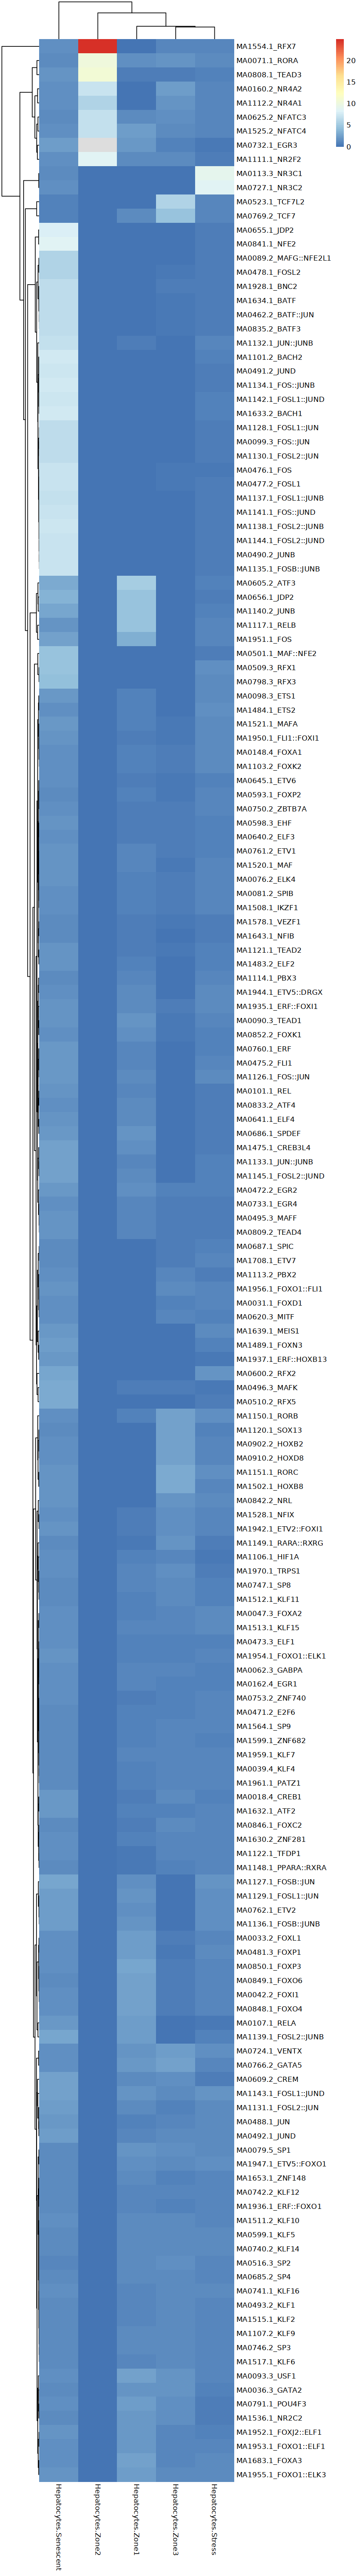

In [134]:
options(repr.plot.height=50)

results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap()

# HSC Markers

In [14]:
results.df.specific <- list()
cells <- c('Activated.HSC','Quescent.HSC','Mesenchymal')

for (cell in cells) {
    df2 <- vroom::vroom(paste0(results.dir, cell, '__241216_WE_',cell,'_Yang_marker_peaks_HSC.bed/knownResults.txt'))
    df2$comparison <- paste0(cell,'.markers')
    df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
    df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
    #Fold change and Log2 Fold change calculation
    FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
    df2$FC<-FC
    L2FC<-log2(abs(FC))
    df2$L2FC<-L2FC
    #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
    # do Log2FC)
    df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
    df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
    df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
    #df3<-df2[df2$padj < .1, ]
    #renaming and rearranging columns because i can't stand the way it looks
    df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
               Perc_Background_Motif=`% of Background Sequences with Motif`, comparison, FC, L2FC, `-Log10p`, padj)
    results.df.specific[[cell]] <- df3
}


Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types

In [15]:
results.df.specific <- bind_rows(results.df.specific, .id = "cell.type")

dim(results.df.specific)
head(results.df.specific)

[1] 2076   10

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Activated.HSC,MA1142.1_FOSL1::JUND,1e-12,27.22,7.83,Activated.HSC.markers,3.476373,1.797583,12,6.920000e-10
Activated.HSC,MA1130.1_FOSL2::JUN,1e-11,29.11,9.49,Activated.HSC.markers,3.067439,1.617035,11,1.384000e-09
Activated.HSC,MA1138.1_FOSL2::JUNB,1e-11,27.22,8.55,Activated.HSC.markers,3.183626,1.670671,11,1.384000e-09
Activated.HSC,MA1144.1_FOSL2::JUND,1e-11,27.22,8.59,Activated.HSC.markers,3.168801,1.663937,11,1.384000e-09
Activated.HSC,MA1135.1_FOSB::JUNB,1e-11,27.22,8.62,Activated.HSC.markers,3.157773,1.658907,11,1.384000e-09
Activated.HSC,MA0099.3_FOS::JUN,1e-10,27.85,9.42,Activated.HSC.markers,2.956476,1.563878,10,5.766667e-09


In [16]:
write.table(results.df.specific, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_HSC_Marker_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

In [138]:
results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif)

Joining with `by = join_by(Motif.Name)`


Motif.Name,sig.motif,cell.type,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MA0017.2_NR2F1,TRUE,Activated.HSC,1e+00,8.86,10.93,Activated.HSC.markers,0.8106130,-0.30291480,0,1.000000e+00
MA0017.2_NR2F1,TRUE,Quescent.HSC,1e-07,18.06,10.71,Quescent.HSC.markers,1.6862745,0.75383941,7,9.746479e-07
MA0017.2_NR2F1,TRUE,Mesenchymal,1e+00,11.57,8.95,Mesenchymal.markers,1.2927374,0.37042928,0,1.000000e+00
MA0018.4_CREB1,TRUE,Activated.HSC,1e+00,5.70,6.68,Activated.HSC.markers,0.8532934,-0.22888618,0,1.000000e+00
MA0018.4_CREB1,TRUE,Quescent.HSC,1e-02,8.64,5.93,Quescent.HSC.markers,1.4569983,0.54299921,2,3.977011e-02
MA0018.4_CREB1,TRUE,Mesenchymal,1e-05,11.11,3.95,Mesenchymal.markers,2.8126582,1.49193426,5,1.384000e-03
MA0027.2_EN1,TRUE,Activated.HSC,1e+00,3.80,3.28,Activated.HSC.markers,1.1585366,0.21230360,0,1.000000e+00
MA0027.2_EN1,TRUE,Quescent.HSC,1e-09,7.72,2.73,Quescent.HSC.markers,2.8278388,1.49969990,9,1.774359e-08
MA0027.2_EN1,TRUE,Mesenchymal,1e+00,1.39,1.30,Mesenchymal.markers,1.0692308,0.09657326,0,1.000000e+00


Joining with `by = join_by(Motif.Name)`


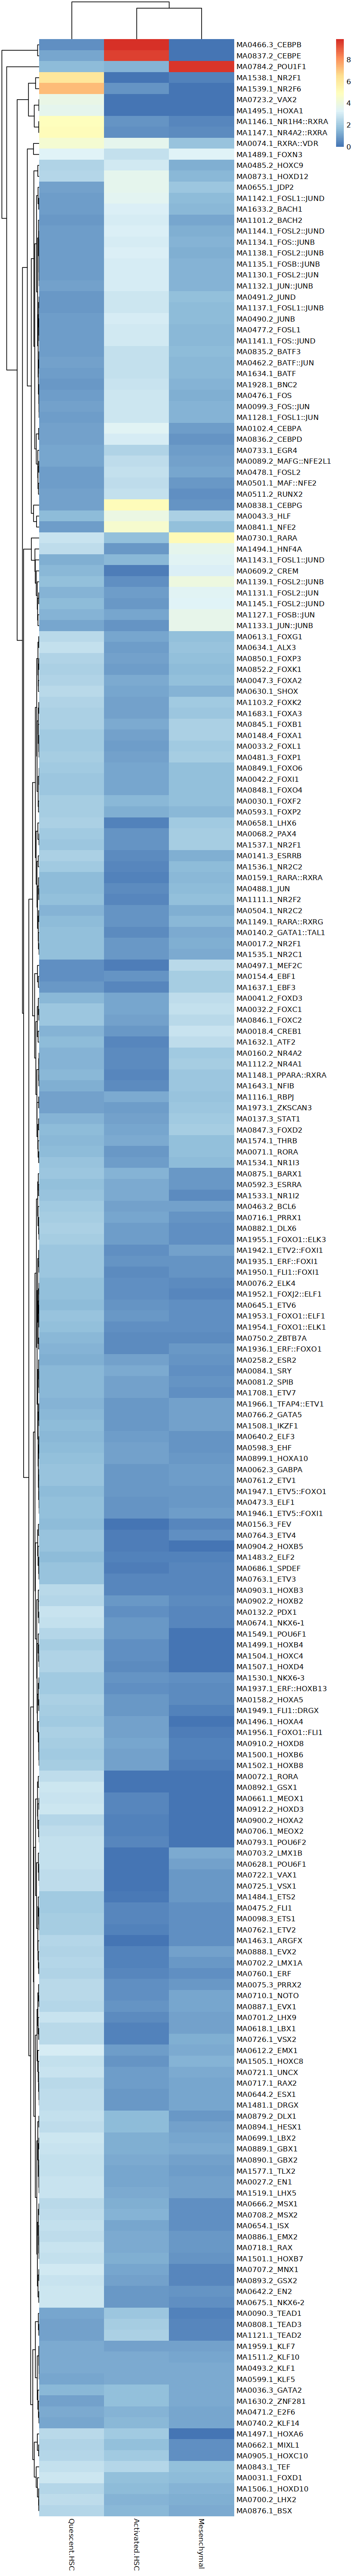

In [139]:
options(repr.plot.height=50)

results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap()

# HSC Specific

In [24]:
results.df.specific <- list()
cells <- c('Activated.HSC','Quescent.HSC','Mesenchymal')

for (cell in cells) {
    df2 <- vroom::vroom(paste0(results.dir, cell, '__241216_WE_',cell,'_Yang_specific_peaks_HSC.bed/knownResults.txt'))
    df2$comparison <- paste0(cell,'.markers')
    df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
    df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
    #Fold change and Log2 Fold change calculation
    FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
    df2$FC<-FC
    L2FC<-log2(abs(FC))
    df2$L2FC<-L2FC
    #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
    # do Log2FC)
    df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
    df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
    df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
    #df3<-df2[df2$padj < .1, ]
    #renaming and rearranging columns because i can't stand the way it looks
    df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
               Perc_Background_Motif=`% of Background Sequences with Motif`, comparison, FC, L2FC, `-Log10p`, padj)
    results.df.specific[[cell]] <- df3
}


Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types

In [25]:
results.df.specific <- bind_rows(results.df.specific, .id = "cell.type")

dim(results.df.specific)
head(results.df.specific)

[1] 2076   10

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Activated.HSC,MA1142.1_FOSL1::JUND,1e-12,27.22,7.83,Activated.HSC.markers,3.476373,1.797583,12,6.920000e-10
Activated.HSC,MA1130.1_FOSL2::JUN,1e-11,29.11,9.49,Activated.HSC.markers,3.067439,1.617035,11,1.384000e-09
Activated.HSC,MA1138.1_FOSL2::JUNB,1e-11,27.22,8.55,Activated.HSC.markers,3.183626,1.670671,11,1.384000e-09
Activated.HSC,MA1144.1_FOSL2::JUND,1e-11,27.22,8.59,Activated.HSC.markers,3.168801,1.663937,11,1.384000e-09
Activated.HSC,MA1135.1_FOSB::JUNB,1e-11,27.22,8.62,Activated.HSC.markers,3.157773,1.658907,11,1.384000e-09
Activated.HSC,MA0099.3_FOS::JUN,1e-10,27.85,9.42,Activated.HSC.markers,2.956476,1.563878,10,5.766667e-09


In [26]:
write.table(results.df.specific, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_HSC_Specific_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

Joining with `by = join_by(Motif.Name)`


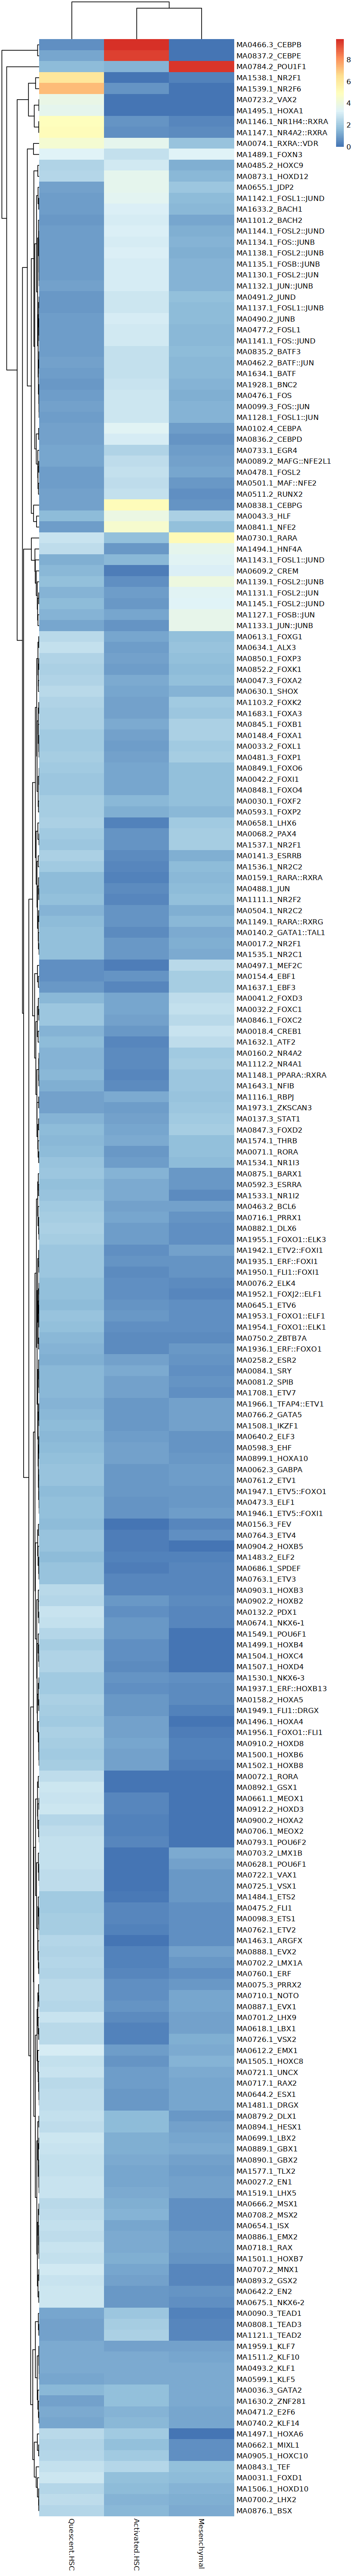

In [144]:
options(repr.plot.height=50)

results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap()

# Subtype Markers

In [27]:
read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/subtype.peaks/listofcells.txt') %>% unlist()

V11                           V12 
              "Activated.HSC"                           "B" 
                          V13                           V14 
   "Central.Vein.Endothelial"               "Cholangiocyte" 
                          V15                           V16 
      "Hepatocytes.Senescent"          "Hepatocytes.Stress" 
                          V17                           V18 
          "Hepatocytes.Zone1"           "Hepatocytes.Zone2" 
                          V19                          V110 
          "Hepatocytes.Zone3"                     "Kupffer" 
                         V111                          V112 
"Lipid.Associated.Macrophage"       "Lymphatic.Endothelial" 
                         V113                          V114 
                 "Macrophage"                        "Mast" 
                         V115                          V116 
                "Mesenchymal"                          "NK" 
                         V117                          V118 
                     "Plasma"                "Quescent.HSC" 
                         V119                          V120 
                    "Schwann"      "Sinusoidal.Endothelial" 
                         V121                          V122 
                          "T"        "Vascular.Endothelial"

In [28]:
results.df.specific <- list()
cells <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/subtype.peaks/listofcells.txt') %>% unlist()

for (cell in cells) {
    df2 <- vroom::vroom(paste0(results.dir, cell, '__241216_WE_',cell,'_Yang_marker_peaks_subtypes.bed/knownResults.txt'))
    df2$comparison <- paste0(cell,'.markers')
    df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
    df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
    df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
    #Fold change and Log2 Fold change calculation
    FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
    df2$FC<-FC
    L2FC<-log2(abs(FC))
    df2$L2FC<-L2FC
    #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
    # do Log2FC)
    df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
    df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
    df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
    #df3<-df2[df2$padj < .1, ]
    #renaming and rearranging columns because i can't stand the way it looks
    df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
               Perc_Background_Motif=`% of Background Sequences with Motif`, comparison, FC, L2FC, `-Log10p`, padj)
    results.df.specific[[cell]] <- df3
}


Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types


ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-

In [29]:
results.df.specific <- bind_rows(results.df.specific, .id = "cell.type")

dim(results.df.specific)
head(results.df.specific)

[1] 15224    10

cell.type,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Activated.HSC,MA1130.1_FOSL2::JUN,1e-150,16.35,6.43,Activated.HSC.markers,2.542768,1.346400,150,6.920000e-148
Activated.HSC,MA1141.1_FOS::JUND,1e-149,15.68,6.05,Activated.HSC.markers,2.591736,1.373919,149,3.460000e-147
Activated.HSC,MA1128.1_FOSL1::JUN,1e-148,16.30,6.45,Activated.HSC.markers,2.527132,1.337501,148,2.306667e-146
Activated.HSC,MA0099.3_FOS::JUN,1e-142,15.89,6.33,Activated.HSC.markers,2.510269,1.327842,142,1.730000e-140
Activated.HSC,MA1144.1_FOSL2::JUND,1e-138,14.76,5.72,Activated.HSC.markers,2.580420,1.367606,138,1.384000e-136
Activated.HSC,MA1135.1_FOSB::JUNB,1e-136,14.71,5.73,Activated.HSC.markers,2.567190,1.360190,136,1.153333e-134


In [30]:
write.table(results.df.specific, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Subtype_Marker_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

In [149]:
results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif)

Joining with `by = join_by(Motif.Name)`


Motif.Name,sig.motif,cell.type,p.value,Perc_Target_Motif,Perc_Background_Motif,comparison,FC,L2FC,-Log10p,padj
<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MA0014.3_PAX5,TRUE,Activated.HSC,1e+00,5.32,5.35,Activated.HSC.markers,0.9943925,-0.008112646,0,1.000000e+00
MA0014.3_PAX5,TRUE,B,1e-01,6.36,5.65,B.markers,1.1256637,0.170775898,1,2.453901e-01
MA0014.3_PAX5,TRUE,Central.Vein.Endothelial,1e-01,6.58,5.82,Central.Vein.Endothelial.markers,1.1305842,0.177068431,1,2.353741e-01
MA0014.3_PAX5,TRUE,Cholangiocyte,1e+00,5.07,5.88,Cholangiocyte.markers,0.8622449,-0.213830408,0,1.000000e+00
MA0014.3_PAX5,TRUE,Hepatocytes.Senescent,1e-01,5.92,5.57,Hepatocytes.Senescent.markers,1.0628366,0.087919848,1,1.982808e-01
MA0014.3_PAX5,TRUE,Hepatocytes.Stress,1e-01,5.74,5.39,Hepatocytes.Stress.markers,1.0649351,0.090765464,1,2.534799e-01
MA0014.3_PAX5,TRUE,Hepatocytes.Zone1,1e+00,5.94,5.86,Hepatocytes.Zone1.markers,1.0136519,0.019562266,0,1.000000e+00
MA0014.3_PAX5,TRUE,Hepatocytes.Zone2,1e+00,5.86,5.82,Hepatocytes.Zone2.markers,1.0068729,0.009881512,0,1.000000e+00
MA0014.3_PAX5,TRUE,Hepatocytes.Zone3,1e+00,5.88,5.74,Hepatocytes.Zone3.markers,1.0243902,0.034765418,0,1.000000e+00


Joining with `by = join_by(Motif.Name)`


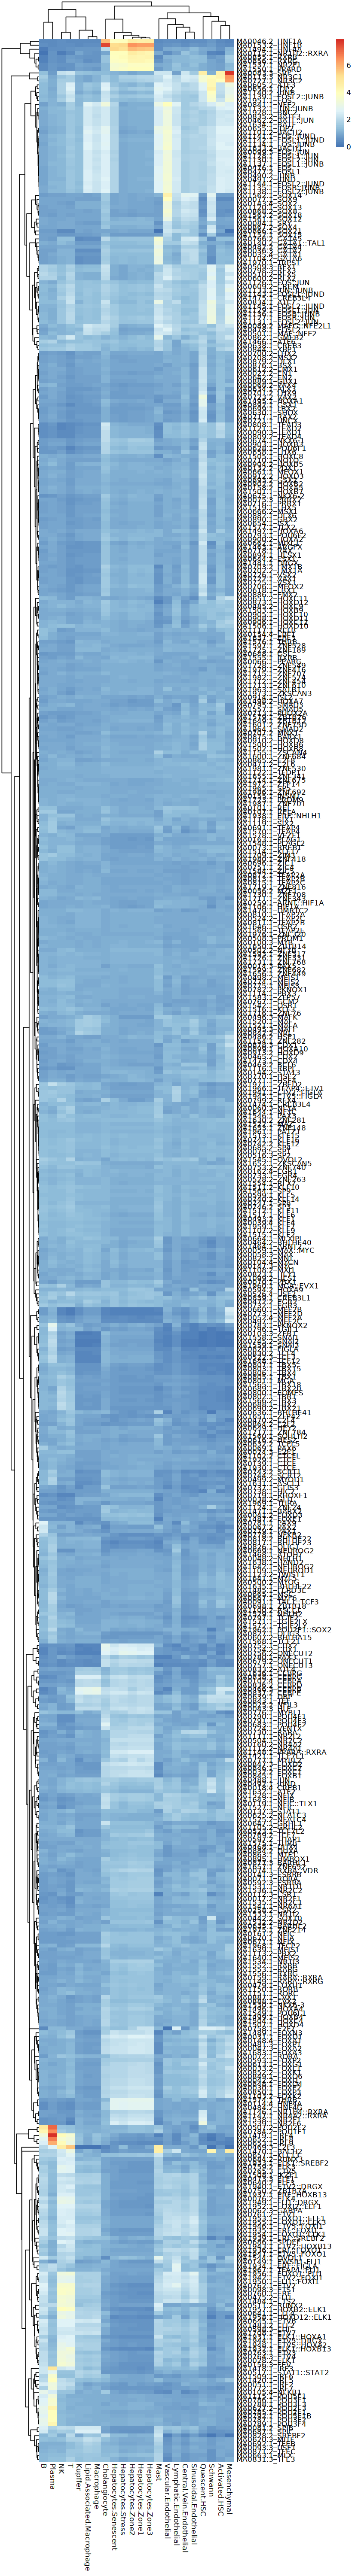

In [150]:
options(repr.plot.height=50)

results.df.specific %>%
    group_by(Motif.Name) %>%
    summarise(sig.motif=any(padj < 0.05)) %>%
    full_join(results.df.specific) %>%
    filter(sig.motif) %>%
    select(cell.type, Motif.Name, FC) %>%
    pivot_wider(values_from = FC, names_from = cell.type) %>%
    tibble::column_to_rownames(var='Motif.Name') %>%
    pheatmap()

# Differential Peaks

In [178]:
results.df <- list()
cells <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/listofcells.txt') %>% unlist()
cells

V11             V12             V13             V14             V15 
            "B" "Cholangiocyte"   "Endothelial"   "Hepatocytes"           "HSC" 
            V16             V17             V18             V19            V110 
         "Mast"       "Myeloid"            "NK"       "Schwann"             "T"

In [185]:
modalities <- c('ATAC',
              'H3K27ac','H3K27ac_ATAC','H3K27ac_TSS',
              'H3K27me3','H3K27me3_ATAC','H3K27me3_TSS')
modalities

[1] "ATAC"          "H3K27ac"       "H3K27ac_ATAC"  "H3K27ac_TSS"  
[5] "H3K27me3"      "H3K27me3_ATAC" "H3K27me3_TSS"

In [182]:
directions <- c('up','down')
directions

[1] "up"   "down"

In [183]:
significance_levels <- c('nominal','padj')
significance_levels

[1] "nominal" "padj"

In [187]:
contrasts <- c('Fibrosis.stage','MASL_vs_Control','MASH_vs_Control','MASH_ALL_vs_Control','MetALD_vs_Control')
contrasts

[1] "Fibrosis.stage"      "MASL_vs_Control"     "MASH_vs_Control"    
[4] "MASH_ALL_vs_Control" "MetALD_vs_Control"

In [188]:
cell <- cells[1]
modality <- modalities[1]
direction <- directions[1]
sig <- significance_levels[1]
contrast <- contrasts[1]

In [189]:
paste0(results.dir, cell, '_',modality,'_',direction,'_',sig,'__',modality,'.',
       cell,'_',contrast,'.dds.res.', sig, '.',direction,'.bed')
# B_ATAC_up_nominal__ATAC.B_Fibrosis.stage.dds.res.nominal.up.bed

# T_H3K27me3_TSS_up_nominal__H3K27me3_TSS.T_MetALD_vs_Control.dds.res.nominal.up.bed

[1] "/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/outs/B_ATAC_up_nominal__ATAC.B_Fibrosis.stage.dds.res.nominal.up.bed"

In [194]:
results.df <- data.frame()
cells <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/listofcells.txt') %>% unlist()

for (cell in cells) {
    for (modality in modalities) {
        for (direction in directions) {
            for (sig in significance_levels) {
                for (contrast in contrasts) {
                    file <- paste0(results.dir, cell, '_',modality,'_',direction,'_',sig,'__',modality,'.',
                                   cell,'_',contrast,'.dds.res.', sig, '.',direction,'.bed/')
                    if (dir.exists(file)) {
                        df2 <- vroom::vroom(paste0(file,'knownResults.txt'))
                        df2$cell <- cell
                        df2$modality <- modality
                        df2$direction <- direction
                        df2$sig <- sig
                        df2$contrast <- contrast
                        df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
                        df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
                        df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
                        df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
                        #Fold change and Log2 Fold change calculation
                        FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
                        df2$FC<-FC
                        L2FC<-log2(abs(FC))
                        df2$L2FC<-L2FC
                        #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
                        # do Log2FC)
                        df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
                        df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
                        df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
                        #df3<-df2[df2$padj < .1, ]
                        #renaming and rearranging columns because i can't stand the way it looks
                        df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
                                   Perc_Background_Motif=`% of Background Sequences with Motif`, cell, 
                                    modality, direction, sig, contrast, FC, L2FC, `-Log10p`, padj)
                        results.df <- rbind(results.df, df3)
                    }
                }
            }
        }
    }
}

dim(results.df)
head(results.df)

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

...

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

[1] 384060     13

Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,modality,direction,sig,contrast,FC,L2FC,-Log10p,padj
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MA0627.2_POU2F3,1e-42,10.36,4.80,B,ATAC,up,nominal,Fibrosis.stage,2.158333,1.1099177,42,6.920000e-40
MA0785.1_POU2F1,1e-39,9.57,4.42,B,ATAC,up,nominal,Fibrosis.stage,2.165158,1.1144726,39,2.306667e-37
MA0792.1_POU5F1B,1e-39,10.22,4.90,B,ATAC,up,nominal,Fibrosis.stage,2.085714,1.0605415,39,2.306667e-37
MA1115.1_POU5F1,1e-37,11.41,5.85,B,ATAC,up,nominal,Fibrosis.stage,1.950427,0.9637903,37,1.730000e-35
MA0789.1_POU3F4,1e-31,8.02,3.78,B,ATAC,up,nominal,Fibrosis.stage,2.121693,1.0852160,31,1.384000e-29
MA0786.1_POU3F1,1e-26,8.51,4.40,B,ATAC,up,nominal,Fibrosis.stage,1.934091,0.9516556,26,9.885714e-25


In [202]:
results.df <- group_by(results.df, cell, modality, sig, contrast) %>%
    mutate(q.value=qvalue(p.value)$qvalues)

In [203]:
write.table(results.df, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Differential_Peaks_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')

In [9]:
results.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Differential_Peaks_JASPAR2022.tsv', header=T)

dim(results.df)
head(results.df)

[1] 384060     15

,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,modality,direction,sig,contrast,FC,L2FC,X.Log10p,padj,qval,q.value
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,MA0627.2_POU2F3,1e-42,10.36,4.80,B,ATAC,up,nominal,Fibrosis.stage,2.158333,1.1099177,42,6.920000e-40,1.384000e-39,1.384000e-39
2,MA0785.1_POU2F1,1e-39,9.57,4.42,B,ATAC,up,nominal,Fibrosis.stage,2.165158,1.1144726,39,2.306667e-37,4.613333e-37,4.613333e-37
3,MA0792.1_POU5F1B,1e-39,10.22,4.90,B,ATAC,up,nominal,Fibrosis.stage,2.085714,1.0605415,39,2.306667e-37,4.613333e-37,4.613333e-37
4,MA1115.1_POU5F1,1e-37,11.41,5.85,B,ATAC,up,nominal,Fibrosis.stage,1.950427,0.9637903,37,1.730000e-35,3.460000e-35,3.460000e-35
5,MA0789.1_POU3F4,1e-31,8.02,3.78,B,ATAC,up,nominal,Fibrosis.stage,2.121693,1.0852160,31,1.384000e-29,2.768000e-29,2.768000e-29
6,MA0786.1_POU3F1,1e-26,8.51,4.40,B,ATAC,up,nominal,Fibrosis.stage,1.934091,0.9516556,26,9.885714e-25,1.977143e-24,1.977143e-24


In [10]:
filter(results.df, str_detect(Motif.Name, 'CREB')) %>%
    arrange(q.value)

Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,modality,direction,sig,contrast,FC,L2FC,X.Log10p,padj,qval,q.value
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
MA0018.4_CREB1,1e-93,9.06,6.69,Hepatocytes,ATAC,up,nominal,Fibrosis.stage,1.354260,0.4375048,93,1.504348e-92,1.922222e-92,1.922222e-92
MA0018.4_CREB1,1e-71,9.74,7.05,Hepatocytes,ATAC,up,padj,Fibrosis.stage,1.381560,0.4662985,71,1.258182e-70,1.590805e-70,1.590805e-70
MA0018.4_CREB1,1e-62,9.95,7.21,Hepatocytes,ATAC,up,nominal,MASH_ALL_vs_Control,1.380028,0.4646973,62,1.537778e-61,2.096970e-61,2.096970e-61
MA0018.4_CREB1,1e-49,10.90,6.55,HSC,ATAC,down,nominal,MetALD_vs_Control,1.664122,0.7347613,49,1.305660e-48,1.572727e-48,1.572727e-48
MA0018.4_CREB1,1e-49,8.90,6.92,Cholangiocyte,ATAC,up,nominal,Fibrosis.stage,1.286127,0.3630333,49,2.035294e-48,4.070588e-48,4.070588e-48
MA0018.4_CREB1,1e-43,9.93,6.27,HSC,ATAC,down,nominal,MASH_ALL_vs_Control,1.583732,0.6633283,43,1.193103e-42,1.472340e-42,1.472340e-42
MA0018.4_CREB1,1e-43,9.87,7.25,Hepatocytes,ATAC,up,nominal,MASH_vs_Control,1.361379,0.4450691,43,1.647619e-42,2.428070e-42,2.428070e-42
MA0018.4_CREB1,1e-43,10.29,7.39,Cholangiocyte,ATAC,up,padj,Fibrosis.stage,1.392422,0.4775967,43,2.096970e-42,4.193939e-42,4.193939e-42
MA0018.4_CREB1,1e-43,9.43,7.11,Cholangiocyte,ATAC,up,nominal,MASH_ALL_vs_Control,1.326301,0.4074082,43,2.306667e-42,4.613333e-42,4.613333e-42


In [11]:
filter(results.df, cell=='Hepatocytes' & sig == 'padj') %>%
    arrange(q.value)

Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,modality,direction,sig,contrast,FC,L2FC,X.Log10p,padj,qval,q.value
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
MA1138.1_FOSL2::JUNB,1e-307,20.77,6.02,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.450166,1.7866658,307,2.562963e-306,5.125926e-306,5.125926e-306
MA1134.1_FOS::JUNB,1e-307,19.41,5.30,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.662264,1.8727359,307,2.562963e-306,5.125926e-306,5.125926e-306
MA1135.1_FOSB::JUNB,1e-307,20.80,6.09,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.415435,1.7720694,307,2.562963e-306,5.125926e-306,5.125926e-306
MA1144.1_FOSL2::JUND,1e-307,20.51,5.96,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.441275,1.7829433,307,2.562963e-306,5.125926e-306,5.125926e-306
MA0476.1_FOS,1e-307,20.81,6.14,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.389251,1.7609664,307,2.562963e-306,5.125926e-306,5.125926e-306
MA1141.1_FOS::JUND,1e-307,20.88,6.18,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.378641,1.7564430,307,2.562963e-306,5.125926e-306,5.125926e-306
MA1130.1_FOSL2::JUN,1e-307,21.73,6.71,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.238450,1.6953035,307,2.562963e-306,5.125926e-306,5.125926e-306
MA1137.1_FOSL1::JUNB,1e-307,21.15,6.40,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.304688,1.7245139,307,2.562963e-306,5.125926e-306,5.125926e-306
MA1128.1_FOSL1::JUN,1e-307,21.84,6.80,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.211765,1.6833662,307,2.562963e-306,5.125926e-306,5.125926e-306


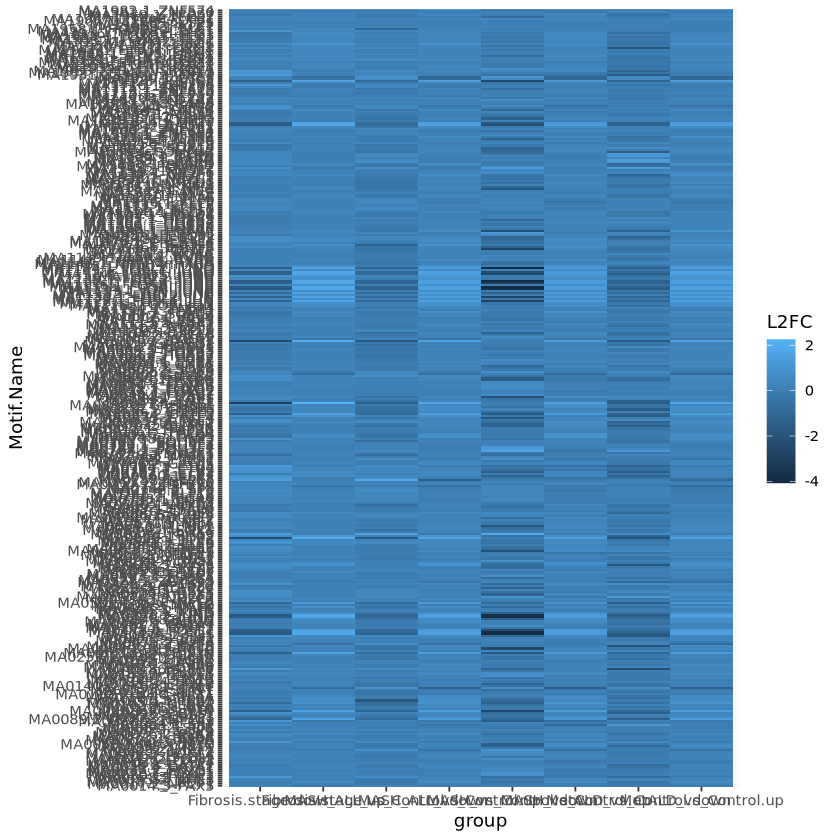

In [12]:
sig.motifs <- filter(results.df, cell=='Hepatocytes' & modality=='ATAC' & sig == 'padj') %>%
    filter(qval < 0.01) %>%
    select(Motif.Name) %>%
    unlist() %>%
    unique()

plot.data <- filter(results.df, cell=='Hepatocytes' & modality=='ATAC' & sig == 'padj') %>%
    filter(Motif.Name %in% sig.motifs) %>%
    mutate(group=paste0(contrast,'.',direction)) %>%
    mutate(label=ifelse(qval > 0.05, '',
                  ifelse(qval >0.01, '*',
                  ifelse(qval > 0.001, '**',
                  ifelse(qval > 0.0001, '***','****'))))) %>%
    mutate(L2FC=ifelse(is.infinite(L2FC), 0, L2FC))

ggplot(plot.data, aes(x=group, y=Motif.Name, fill=L2FC)) + geom_tile()

In [13]:
plot.data %>%
    filter(Motif.Name=='MA1138.1_FOSL2::JUNB')

Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,modality,direction,sig,contrast,FC,L2FC,X.Log10p,padj,qval,q.value,group,label
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
MA1138.1_FOSL2::JUNB,1e-307,20.77,6.02,Hepatocytes,ATAC,up,padj,Fibrosis.stage,3.45016611,1.786666,307,2.562963e-306,5.125926e-306,5.125926e-306,Fibrosis.stage.up,****
MA1138.1_FOSL2::JUNB,1e-78,21.70,8.43,Hepatocytes,ATAC,up,padj,MASH_vs_Control,2.57413998,1.364091,78,1.730000e-76,3.460000e-76,3.460000e-76,MASH_vs_Control.up,****
MA1138.1_FOSL2::JUNB,1e-307,22.20,7.83,Hepatocytes,ATAC,up,padj,MASH_ALL_vs_Control,2.83524904,1.503475,307,3.295238e-306,6.590476e-306,6.590476e-306,MASH_ALL_vs_Control.up,****
MA1138.1_FOSL2::JUNB,1e-275,23.27,8.20,Hepatocytes,ATAC,up,padj,MetALD_vs_Control,2.83780488,1.504775,275,6.920000e-273,1.384000e-272,1.384000e-272,MetALD_vs_Control.up,****
MA1138.1_FOSL2::JUNB,1e+00,1.38,4.40,Hepatocytes,ATAC,down,padj,Fibrosis.stage,0.31363636,-1.672835,0,1.000000e+00,1.000000e+00,1.000000e+00,Fibrosis.stage.down,
MA1138.1_FOSL2::JUNB,1e+00,0.21,3.47,Hepatocytes,ATAC,down,padj,MASH_vs_Control,0.06051873,-4.046474,0,1.000000e+00,1.000000e+00,1.000000e+00,MASH_vs_Control.down,
MA1138.1_FOSL2::JUNB,1e+00,1.58,3.54,Hepatocytes,ATAC,down,padj,MASH_ALL_vs_Control,0.44632768,-1.163825,0,1.000000e+00,1.000000e+00,1.000000e+00,MASH_ALL_vs_Control.down,
MA1138.1_FOSL2::JUNB,1e+00,2.28,5.37,Hepatocytes,ATAC,down,padj,MetALD_vs_Control,0.42458101,-1.235888,0,1.000000e+00,1.000000e+00,1.000000e+00,MetALD_vs_Control.down,


In [20]:
nmf.data <- select(plot.data, Motif.Name, group, FC) %>%
    pivot_wider(names_from = group, values_from = FC) %>%
    tibble::column_to_rownames('Motif.Name')

In [21]:
library(NMF)

In [22]:
sum(nmf.data > 0)
sum(nmf.data < 0)


[1] 2979

[1] 0

In [40]:
# Perform NMF
rank <- 7  # Number of factors
nmf_result <- nmf(nmf.data, rank, .options = "v")  # Verbose option

# Extract basis (W) and coefficient (H) matrices
W <- basis(nmf_result)  # Rows = features, columns = factors
H <- coef(nmf_result)   # Rows = factors, columns = samples

# Sort rows and columns by the dominant factor
row_order <- order(max.col(W))  # Order features by their dominant factor
col_order <- order(max.col(t(H)))  # Order samples by their dominant factor

# Reorder the matrix
mat_reordered <- nmf.data[row_order, col_order]

NMF algorithm: 'brunet'

NMF seeding method: random



Iterations:  550/2000
DONE (converged at 560/2000 iterations)


In [41]:
colnames(nmf.data)[col_order]

[1] "MASH_vs_Control.down"     "Fibrosis.stage.down"     
[3] "MASH_ALL_vs_Control.down" "Fibrosis.stage.up"       
[5] "MASH_ALL_vs_Control.up"   "MetALD_vs_Control.up"    
[7] "MASH_vs_Control.up"       "MetALD_vs_Control.down"

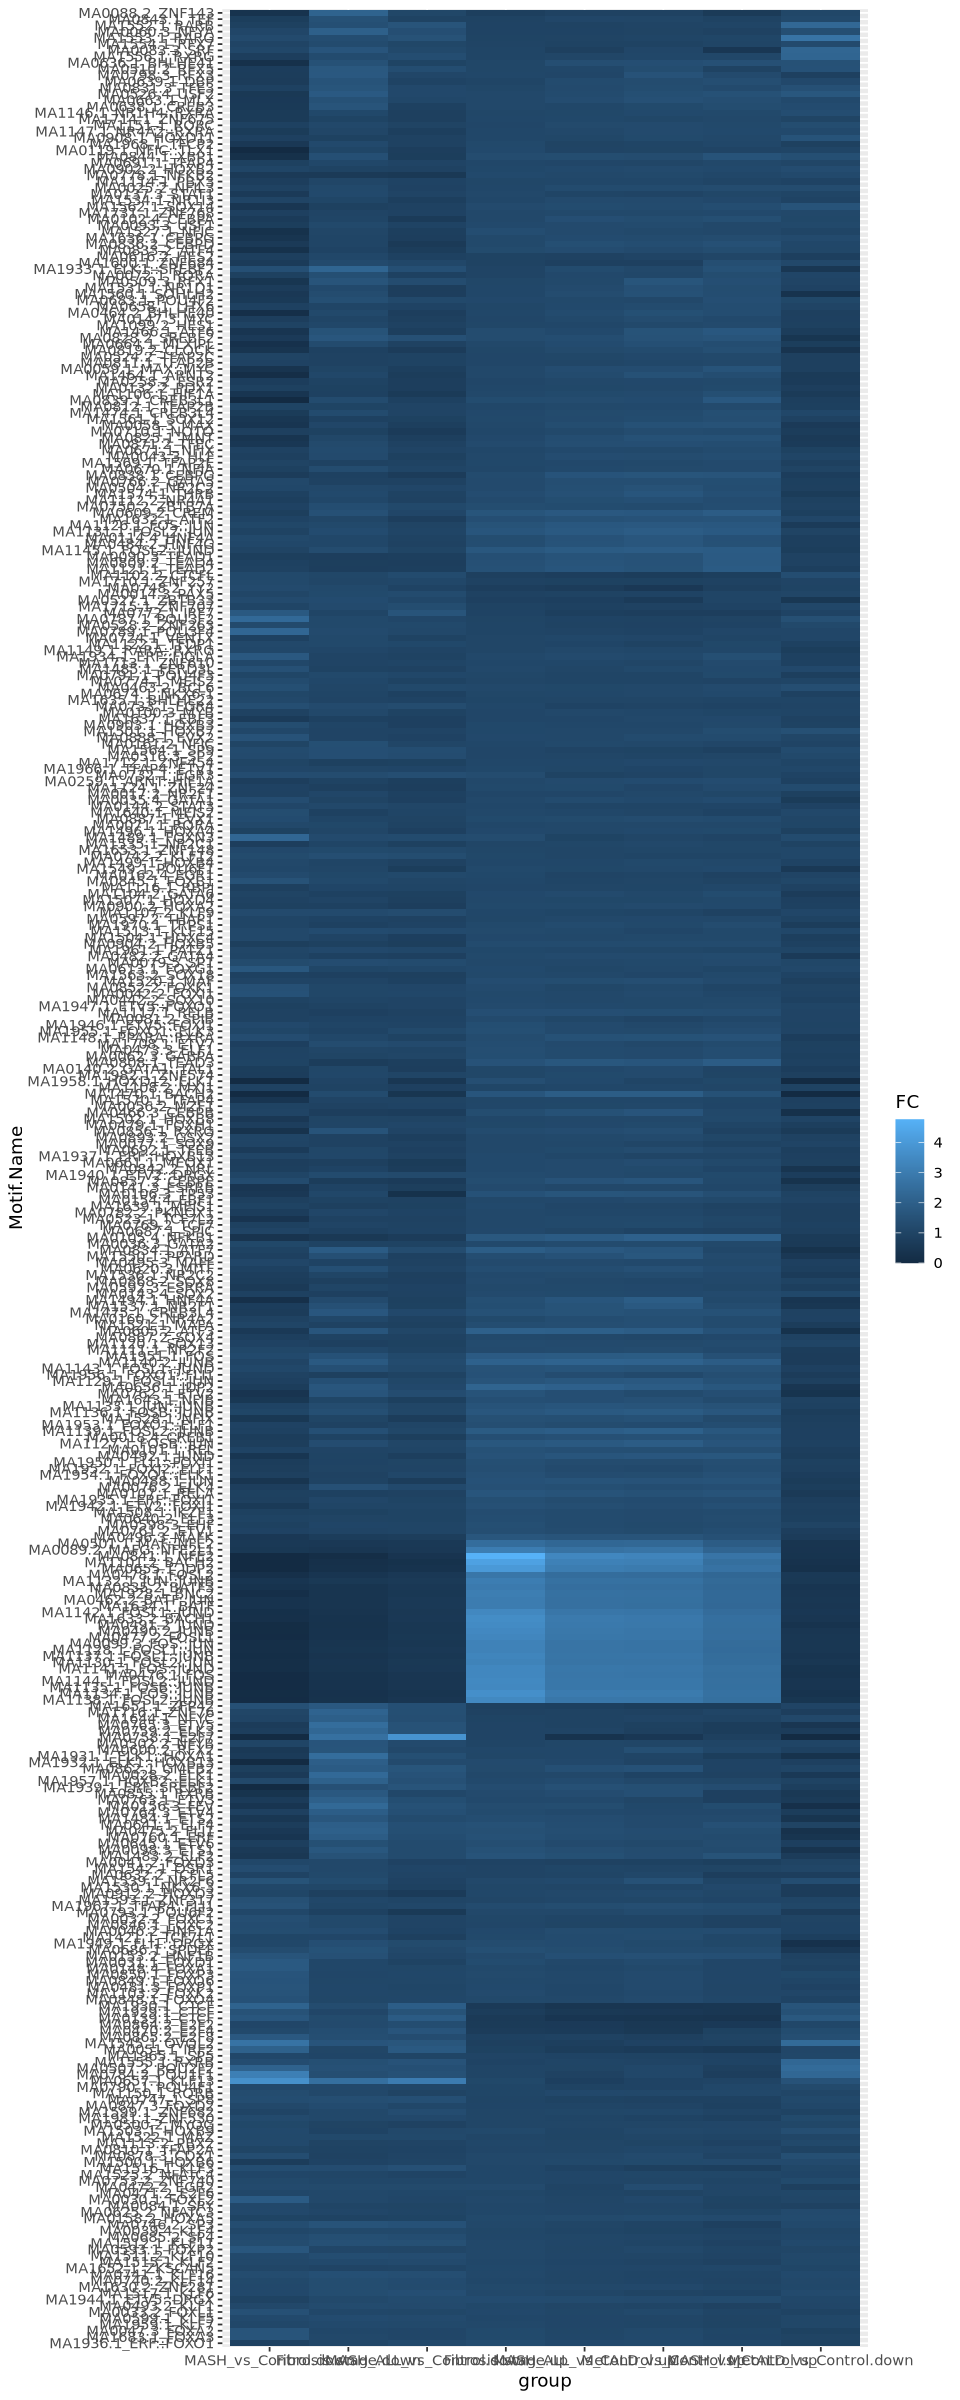

In [43]:
options(repr.plot.width=8, repr.plot.height=20)
plot.data$Motif.Name <- factor(plot.data$Motif.Name, levels=rownames(nmf.data)[row_order])
plot.data$group <- factor(plot.data$group, levels=colnames(nmf.data)[col_order])

ggplot(plot.data, aes(x=group, y=Motif.Name, fill=FC)) + geom_tile()

In [1]:
results.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241220_Differential_Peaks_JASPAR2022.tsv', header=T)

dim(results.df)
head(results.df)

[1] 384060     15

,Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,modality,direction,sig,contrast,FC,L2FC,X.Log10p,padj,qval,q.value
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1,MA0627.2_POU2F3,1e-42,10.36,4.80,B,ATAC,up,nominal,Fibrosis.stage,2.158333,1.1099177,42,6.920000e-40,1.384000e-39,1.384000e-39
2,MA0785.1_POU2F1,1e-39,9.57,4.42,B,ATAC,up,nominal,Fibrosis.stage,2.165158,1.1144726,39,2.306667e-37,4.613333e-37,4.613333e-37
3,MA0792.1_POU5F1B,1e-39,10.22,4.90,B,ATAC,up,nominal,Fibrosis.stage,2.085714,1.0605415,39,2.306667e-37,4.613333e-37,4.613333e-37
4,MA1115.1_POU5F1,1e-37,11.41,5.85,B,ATAC,up,nominal,Fibrosis.stage,1.950427,0.9637903,37,1.730000e-35,3.460000e-35,3.460000e-35
5,MA0789.1_POU3F4,1e-31,8.02,3.78,B,ATAC,up,nominal,Fibrosis.stage,2.121693,1.0852160,31,1.384000e-29,2.768000e-29,2.768000e-29
6,MA0786.1_POU3F1,1e-26,8.51,4.40,B,ATAC,up,nominal,Fibrosis.stage,1.934091,0.9516556,26,9.885714e-25,1.977143e-24,1.977143e-24


In [3]:
unique(results.df$modality)

[1] "ATAC"         "H3K27ac"      "H3K27ac_TSS"  "H3K27me3"     "H3K27me3_TSS"

In [11]:
library(dplyr)
filter(results.df, modality %in% c('ATAC') & sig=='padj') %>%
    select(-q.value, -sig) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/For.Parul.neo4j/motifs/disease/241220_WE_CellType_DAC_motifs.tsv',
               sep='\t', col.names=T, row.names=F, quote=F)

# Clusters

In [3]:
results.df <- list()
cells <- c('Hepatocytes','Endothelial','Myeloid','HSC')
cells

[1] "Hepatocytes" "Endothelial" "Myeloid"     "HSC"

In [6]:
contrasts <- c('MASH','MASH_on','MASL','MASL_on','MetALD')
contrasts
results.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/outs/'

[1] "MASH"    "MASH_on" "MASL"    "MASL_on" "MetALD"

In [8]:
results.df <- data.frame()
cells <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/listofcells.txt') %>% unlist()

for (cell in cells) {
    for (contrast in contrasts) {
        file <- paste0(results.dir, cell, '__241217_WE_',cell,'_disease_',contrast,'_clusters.bed/')
        if (file.exists(paste0(file,'knownResults.txt'))) {
            df2 <- vroom::vroom(paste0(file,'knownResults.txt'))
            df2$cell <- cell
            df2$contrast <- contrast
            df2$`% of Target Sequences with Motif`<-gsub("[%]", "", df2$`% of Target Sequences with Motif`)
            df2$`% of Background Sequences with Motif`<-gsub("[%]", "", df2$`% of Background Sequences with Motif`)
            df2$`% of Target Sequences with Motif`<-as.numeric(df2$`% of Target Sequences with Motif`)
            df2$`% of Background Sequences with Motif`<-as.numeric(df2$`% of Background Sequences with Motif`)
            #Fold change and Log2 Fold change calculation
            FC<-(df2$`% of Target Sequences with Motif`)/df2$`% of Background Sequences with Motif`
            df2$FC<-FC
            L2FC<-log2(abs(FC))
            df2$L2FC<-L2FC
            #Replacing q-value with our padj (same method but doesn't round to 0 and 1 so we don't get infinity when we 
            # do Log2FC)
            df2$`-Log10p`<- -log(x = df2$`P-value`, base = 10)
            df2$padj<-p.adjust(p = df2$`P-value`, method = "BH", n = nrow(df2)) 
            df2$`-Log10padj`<- -log(x = df2$padj, base = 10)
            #df3<-df2[df2$padj < .1, ]
            #renaming and rearranging columns because i can't stand the way it looks
            df3<-select(df2, Motif.Name=`Motif Name`, p.value=`P-value`, Perc_Target_Motif=`% of Target Sequences with Motif`,
                       Perc_Background_Motif=`% of Background Sequences with Motif`, cell, 
                        contrast, FC, L2FC, `-Log10p`, padj)
            results.df <- rbind(results.df, df3)
        }
    }
}

dim(results.df)
head(results.df)

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 692 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): Motif Name, Consensus, % of Target Sequences with Motif, % of Backg...
dbl (5): P-value, Log P-value, q-value (Benjamini), # of Target Sequences wi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set 

[1] 13840    10

Motif.Name,p.value,Perc_Target_Motif,Perc_Background_Motif,cell,contrast,FC,L2FC,-Log10p,padj
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
MA1138.1_FOSL2::JUNB,1e-56,9.34,6.64,Endothelial,MASH,1.406627,0.4922393,56,6.920000e-54
MA1135.1_FOSB::JUNB,1e-55,9.40,6.70,Endothelial,MASH,1.402985,0.4884997,55,1.730000e-53
MA1130.1_FOSL2::JUN,1e-55,10.17,7.36,Endothelial,MASH,1.381793,0.4665420,55,1.730000e-53
MA1144.1_FOSL2::JUND,1e-55,9.29,6.62,Endothelial,MASH,1.403323,0.4888474,55,1.730000e-53
MA0476.1_FOS,1e-54,9.43,6.75,Endothelial,MASH,1.397037,0.4823703,54,9.885714e-53
MA1137.1_FOSL1::JUNB,1e-54,9.64,6.94,Endothelial,MASH,1.389049,0.4740975,54,9.885714e-53


In [247]:
write.table(results.df, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/241217_Clusters_JASPAR2022.tsv',
           col.names=T, row.names=F, quote=F,sep='\t')